In [1]:
import pandas as pd
import numpy as np
import pygeohash as pgh
import matplotlib.pyplot as plt

In [19]:
train_df = pd.read_csv("../data/features/train_features_RJ91.csv")
test_df = pd.read_csv("../data/raw/test.csv")

In [3]:
train_df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,...,geo_cluster_25,geo_cluster_50,geohash_freq,day_mod_7,is_week_start,is_week_end,period,road_hour,weather_hour,cluster_hour
0,0,qp02z1,48,0:0,0.048804,Unknown,1,Not Allowed,No,16.415162,...,9,2,33.0,6,0,1,night,Unknown_0,Unknown_0,9_0
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,...,9,2,89.0,6,0,1,night,Residential_0,Sunny_0,9_0
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,...,16,47,67.0,6,0,1,night,Residential_0,Sunny_0,16_0
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,16.415162,...,8,36,42.0,6,0,1,night,Residential_0,Rainy_0,8_0
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,...,9,2,36.0,6,0,1,night,Residential_0,Rainy_0,9_0


In [4]:
train_df.columns

Index(['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType',
       'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather',
       'is_train', 'hour', 'minute', 'total_minutes', 'lat', 'lon', 'lat_lon',
       'lat_plus_lon', 'lat_minus_lon', 'geo_cluster_10', 'geo_cluster_25',
       'geo_cluster_50', 'geohash_freq', 'day_mod_7', 'is_week_start',
       'is_week_end', 'period', 'road_hour', 'weather_hour', 'cluster_hour'],
      dtype='str')

In [6]:
for col in train_df.columns:
    print(f"Column: {col}")
    print(train_df[col].describe())

Column: Index
count    77299.000000
mean     38649.000000
std      22314.443566
min          0.000000
25%      19324.500000
50%      38649.000000
75%      57973.500000
max      77298.000000
Name: Index, dtype: float64
Column: geohash
count      77299
unique      1249
top       qp094q
freq         105
Name: geohash, dtype: object
Column: day
count    77299.000000
mean        48.101838
std          0.302438
min         48.000000
25%         48.000000
50%         48.000000
75%         48.000000
max         49.000000
Name: day, dtype: float64
Column: timestamp
count     77299
unique       96
top         2:0
freq       1778
Name: timestamp, dtype: object
Column: demand
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64
Column: RoadType
count           77299
unique              4
top       Residential
freq            69230
Name: RoadType, d

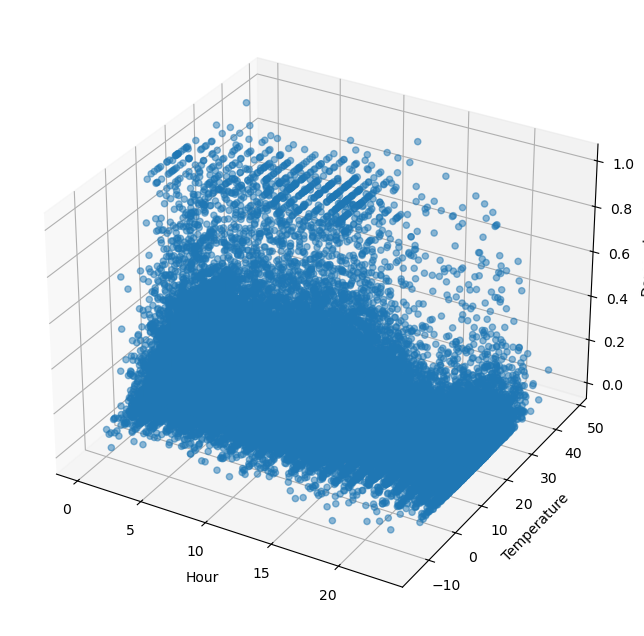

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    train_df['hour'],
    train_df['Temperature'],
    train_df['demand'],
    alpha=0.5
)

ax.set_xlabel('Hour')
ax.set_ylabel('Temperature')
ax.set_zlabel('Demand')

plt.show()

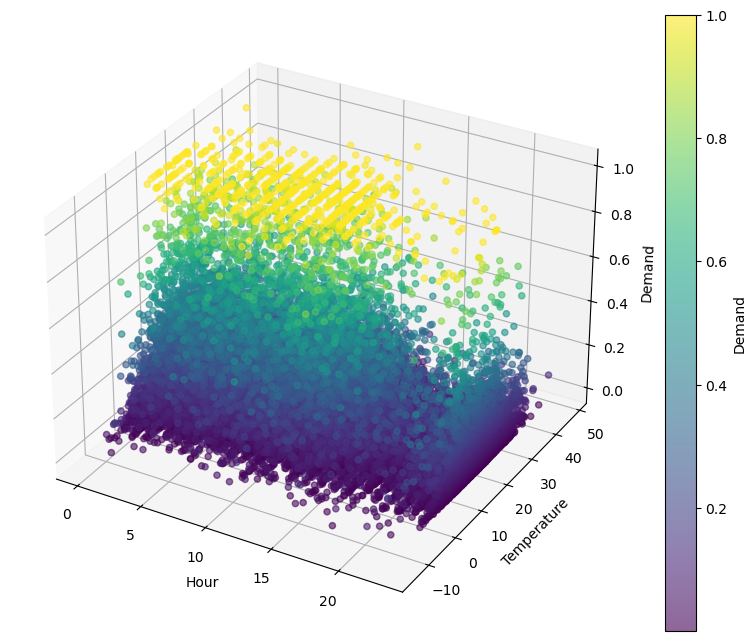

In [8]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    train_df['hour'],
    train_df['Temperature'],
    train_df['demand'],
    c=train_df['demand'],
    alpha=0.6
)

plt.colorbar(sc, label='Demand')

ax.set_xlabel('Hour')
ax.set_ylabel('Temperature')
ax.set_zlabel('Demand')

plt.show()

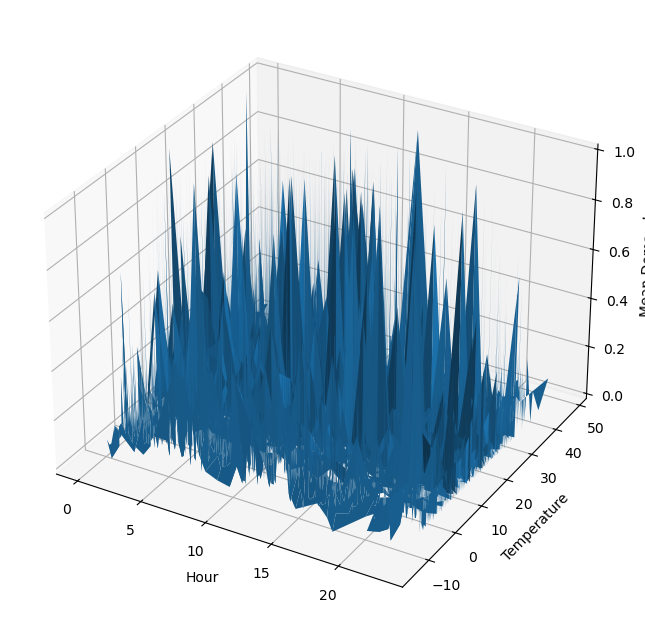

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

surface_df = (
    train_df
    .groupby(['hour', 'Temperature'])['demand']
    .mean()
    .reset_index()
)

pivot = surface_df.pivot(
    index='Temperature',
    columns='hour',
    values='demand'
)

X = pivot.columns.values
Y = pivot.index.values

X, Y = np.meshgrid(X, Y)
Z = pivot.values

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z)

ax.set_xlabel('Hour')
ax.set_ylabel('Temperature')
ax.set_zlabel('Mean Demand')

plt.show()

In [ ]:
import itertools
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

numeric_cols = [
    'hour',
    'Temperature',
    'lat',
    'lon',
    'NumberofLanes',
    'geohash_freq',
    'total_minutes'
]

for col1, col2 in itertools.combinations(numeric_cols, 2):

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(
        train_df[col1],
        train_df[col2],
        train_df['demand'],
        c=train_df['demand'],
        alpha=0.5
    )

    ax.set_xlabel(col1)
    ax.set_ylabel(col2)
    ax.set_zlabel('demand')

    plt.colorbar(sc, label='Demand')
    plt.title(f'{col1} vs {col2} vs Demand')

    plt.show()

In [11]:
import itertools
import os
import matplotlib.pyplot as plt

save_dir = "plots/3d_feature_pairs"
os.makedirs(save_dir, exist_ok=True)

numeric_cols = [
    'hour',
    'Temperature',
    'lat',
    'lon',
    'NumberofLanes',
    'geohash_freq',
    'total_minutes'
]

for col1, col2 in itertools.combinations(numeric_cols, 2):

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(
        train_df[col1],
        train_df[col2],
        train_df['demand'],
        c=train_df['demand'],
        alpha=0.5
    )

    ax.set_xlabel(col1)
    ax.set_ylabel(col2)
    ax.set_zlabel('demand')

    plt.colorbar(sc)

    plt.title(f'{col1} vs {col2} vs Demand')

    filename = f"{col1}_{col2}.png"
    plt.savefig(os.path.join(save_dir, filename), dpi=300)

    plt.close()

print(f"Saved all plots to {save_dir}")

Saved all plots to plots/3d_feature_pairs


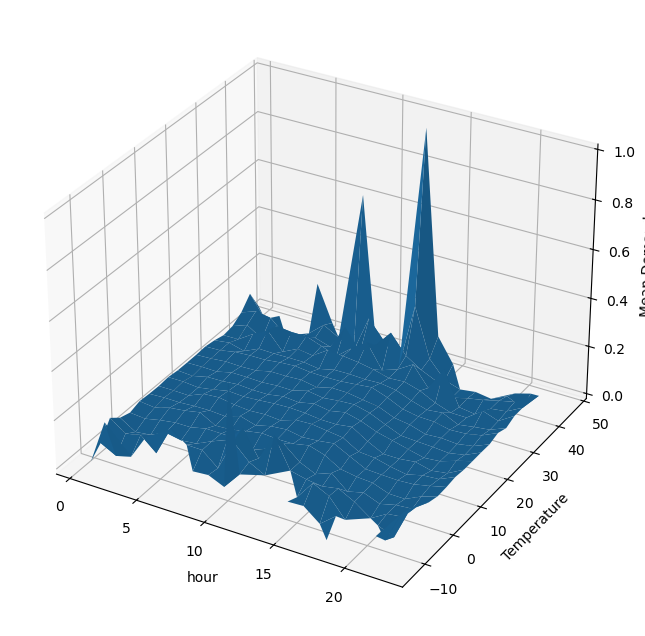

In [12]:
import numpy as np
from scipy.stats import binned_statistic_2d
import matplotlib.pyplot as plt

col1 = 'hour'
col2 = 'Temperature'

stat, x_edge, y_edge, _ = binned_statistic_2d(
    train_df[col1],
    train_df[col2],
    train_df['demand'],
    statistic='mean',
    bins=20
)

X, Y = np.meshgrid(
    (x_edge[:-1] + x_edge[1:]) / 2,
    (y_edge[:-1] + y_edge[1:]) / 2
)

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, stat.T)

ax.set_xlabel(col1)
ax.set_ylabel(col2)
ax.set_zlabel('Mean Demand')

plt.show()

In [13]:
import itertools
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d

save_dir = "plots/surface_plots"
os.makedirs(save_dir, exist_ok=True)

numeric_cols = [
    'hour',
    'total_minutes',
    'Temperature',
    'lat',
    'lon',
    'NumberofLanes',
    'geohash_freq'
]

for col1, col2 in itertools.combinations(numeric_cols, 2):

    df_plot = train_df[[col1, col2, 'demand']].dropna()

    try:
        stat, x_edge, y_edge, _ = binned_statistic_2d(
            df_plot[col1],
            df_plot[col2],
            df_plot['demand'],
            statistic='mean',
            bins=20
        )

        X = (x_edge[:-1] + x_edge[1:]) / 2
        Y = (y_edge[:-1] + y_edge[1:]) / 2

        X, Y = np.meshgrid(X, Y)

        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')

        ax.plot_surface(
            X,
            Y,
            stat.T,
            cmap='viridis'
        )

        ax.set_xlabel(col1)
        ax.set_ylabel(col2)
        ax.set_zlabel('Mean Demand')

        plt.title(f'{col1} vs {col2} → Demand')

        plt.savefig(
            os.path.join(save_dir, f'{col1}_{col2}.png'),
            dpi=300,
            bbox_inches='tight'
        )

        plt.close()

    except Exception as e:
        print(f"Failed for {col1}, {col2}: {e}")

print(f"Saved plots to: {save_dir}")

Saved plots to: plots/surface_plots


In [5]:
train_df.columns

Index(['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType',
       'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather',
       'is_train', 'hour', 'minute', 'total_minutes', 'lat', 'lon', 'lat_lon',
       'lat_plus_lon', 'lat_minus_lon', 'geo_cluster_10', 'geo_cluster_25',
       'geo_cluster_50', 'geohash_freq', 'day_mod_7', 'is_week_start',
       'is_week_end', 'period', 'road_hour', 'weather_hour', 'cluster_hour'],
      dtype='str')

In [7]:
from sklearn.model_selection import train_test_split

train_part, val_part = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.preprocessing import LabelEncoder

cat_cols = [
    'geohash',
    'RoadType',
    'Weather',
    'Landmarks',
    'LargeVehicles',
    'geo_cluster_10',
    'geo_cluster_25',
    'geo_cluster_50'
]

encoders = {}

for col in cat_cols:

    if col not in train_df.columns:
        print(f"Skipping {col} (not found)")
        continue

    le = LabelEncoder()

    train_df[col] = train_df[col].astype(str)

    le.fit(train_df[col])

    train_df[col] = le.transform(train_df[col])

    encoders[col] = le

print("Encoding complete")

Encoding complete


In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

num_cols = [
    'hour',
    'minute',
    'total_minutes',
    'Temperature',
    'lat',
    'lon',
    'lat_lon',
    'lat_plus_lon',
    'lat_minus_lon',
    'NumberofLanes',
    'geohash_freq'
]

X_num = StandardScaler().fit_transform(train_df[num_cols])

pca = PCA()
pca.fit(X_num)

print(pca.explained_variance_ratio_.cumsum())

[0.24493962 0.47193993 0.64937412 0.74085914 0.83175673 0.92239583
 0.99999994 1.         1.         1.         1.        ]


In [10]:
geo_mean = train_df.groupby("geohash")["demand"].mean()

pred = train_df["geohash"].map(geo_mean)

from sklearn.metrics import r2_score

print(r2_score(train_df["demand"], pred))

0.6943288460514747


In [11]:
train_df["geo_hour"] = (
    train_df["geohash"].astype(str)
    + "_"
    + train_df["hour"].astype(str)
)

In [12]:
geo_hour_mean = train_df.groupby("geo_hour")["demand"].mean()

pred = train_df["geo_hour"].map(geo_hour_mean)

from sklearn.metrics import r2_score

print(r2_score(train_df["demand"], pred))

0.9481857672884352


In [13]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_geo_hour = np.zeros(len(train_df))

for train_idx, valid_idx in kf.split(train_df):

    train_fold = train_df.iloc[train_idx]
    valid_fold = train_df.iloc[valid_idx]

    means = (
        train_fold
        .groupby("geo_hour")["demand"]
        .mean()
    )

    global_mean = train_fold["demand"].mean()

    oof_geo_hour[valid_idx] = (
        valid_fold["geo_hour"]
        .map(means)
        .fillna(global_mean)
    )

print(
    "OOF R²:",
    r2_score(
        train_df["demand"],
        oof_geo_hour
    )
)

OOF R²: 0.8947395146488111


In [14]:
train_df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,...,geo_cluster_50,geohash_freq,day_mod_7,is_week_start,is_week_end,period,road_hour,weather_hour,cluster_hour,geo_hour
0,0,588,48,0:0,0.048804,3,1,1,0,16.415162,...,12,33.0,6,0,1,night,Unknown_0,Unknown_0,9_0,588_0
1,1,423,48,0:0,0.118507,1,3,0,1,31.104565,...,12,89.0,6,0,1,night,Residential_0,Sunny_0,9_0,423_0
2,2,557,48,0:0,0.027132,1,1,1,0,25.919267,...,42,67.0,6,0,1,night,Residential_0,Sunny_0,16_0,557_0
3,3,608,48,0:0,0.003272,1,1,1,0,16.415162,...,30,42.0,6,0,1,night,Residential_0,Rainy_0,8_0,608_0
4,4,390,48,0:0,0.010819,1,1,1,0,10.803667,...,12,36.0,6,0,1,night,Residential_0,Rainy_0,9_0,390_0


In [20]:
train_df.columns


Index(['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType',
       'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather',
       'is_train', 'hour', 'minute', 'total_minutes', 'lat', 'lon', 'lat_lon',
       'lat_plus_lon', 'lat_minus_lon', 'geo_cluster_10', 'geo_cluster_25',
       'geo_cluster_50', 'geohash_freq', 'day_mod_7', 'is_week_start',
       'is_week_end', 'period', 'road_hour', 'weather_hour', 'cluster_hour'],
      dtype='str')

In [21]:
train_fe = train_df.copy()

train_fe["geo_hour"] = (
    train_fe["geohash"].astype(str)
    + "_"
    + train_fe["hour"].astype(str)
)

train_fe["geo_period"] = (
    train_fe["geohash"].astype(str)
    + "_"
    + train_fe["period"].astype(str)
)

train_fe["geo_weather"] = (
    train_fe["geohash"].astype(str)
    + "_"
    + train_fe["Weather"].astype(str)
)

train_fe["geo_day"] = (
    train_fe["geohash"].astype(str)
    + "_"
    + train_fe["day"].astype(str)
)

In [22]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold


def create_oof_target_encoding(
    df,
    feature_col,
    target_col="demand",
    n_splits=5,
    random_state=42
):

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    oof_encoded = np.zeros(len(df))

    for train_idx, valid_idx in kf.split(df):

        train_fold = df.iloc[train_idx]
        valid_fold = df.iloc[valid_idx]

        means = (
            train_fold
            .groupby(feature_col)[target_col]
            .mean()
        )

        global_mean = train_fold[target_col].mean()

        oof_encoded[valid_idx] = (
            valid_fold[feature_col]
            .map(means)
            .fillna(global_mean)
        )

    return oof_encoded

In [23]:
interaction_cols = [
    "geo_hour",
    "geo_period",
    "geo_weather",
    "geo_day"
]

for col in interaction_cols:

    print(f"Encoding {col}")

    train_fe[f"{col}_te"] = create_oof_target_encoding(
        train_fe,
        feature_col=col,
        target_col="demand"
    )

Encoding geo_hour
Encoding geo_period
Encoding geo_weather
Encoding geo_day


In [24]:
from sklearn.metrics import r2_score

interaction_cols = [
    "geo_hour",
    "geo_period",
    "geo_weather",
    "geo_day"
]

print("=" * 60)
print("OOF Target Encoding Ceiling Test")
print("=" * 60)

for col in interaction_cols:

    score = r2_score(
        train_fe["demand"],
        train_fe[f"{col}_te"]
    )

    print(
        f"{col:<20} R² = {score:.6f}"
    )

OOF Target Encoding Ceiling Test
geo_hour             R² = 0.894740
geo_period           R² = 0.856094
geo_weather          R² = 0.667692
geo_day              R² = 0.712051


In [25]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score

te_features = [
    "geo_hour_te",
    "geo_period_te",
    "geo_weather_te",
    "geo_day_te"
]

X_te = train_fe[te_features]
y = train_fe["demand"]

model = Ridge(alpha=1.0)

preds = cross_val_predict(
    model,
    X_te,
    y,
    cv=5
)

score = r2_score(y, preds)

print(f"\nCombined TE R² = {score:.6f}")


Combined TE R² = 0.904305


In [26]:
corr = train_fe[
    [
        "geo_hour_te",
        "geo_period_te",
        "geo_weather_te",
        "geo_day_te"
    ]
].corr()

print(corr)

                geo_hour_te  geo_period_te  geo_weather_te  geo_day_te
geo_hour_te        1.000000       0.941587        0.829806    0.836294
geo_period_te      0.941587       1.000000        0.876312    0.880267
geo_weather_te     0.829806       0.876312        1.000000    0.966233
geo_day_te         0.836294       0.880267        0.966233    1.000000


In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    train_fe[te_features],
    train_fe["demand"]
)

importance_df = pd.DataFrame({
    "feature": te_features,
    "importance": rf.feature_importances_
})

print(
    importance_df.sort_values(
        "importance",
        ascending=False
    )
)

          feature  importance
0     geo_hour_te    0.909371
1   geo_period_te    0.040833
3      geo_day_te    0.029672
2  geo_weather_te    0.020123


In [28]:
train_fe.columns

Index(['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType',
       'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather',
       'is_train', 'hour', 'minute', 'total_minutes', 'lat', 'lon', 'lat_lon',
       'lat_plus_lon', 'lat_minus_lon', 'geo_cluster_10', 'geo_cluster_25',
       'geo_cluster_50', 'geohash_freq', 'day_mod_7', 'is_week_start',
       'is_week_end', 'period', 'road_hour', 'weather_hour', 'cluster_hour',
       'geo_hour', 'geo_period', 'geo_weather', 'geo_day', 'geo_hour_te',
       'geo_period_te', 'geo_weather_te', 'geo_day_te'],
      dtype='str')

In [29]:
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

In [33]:
features_A = [
    'geohash',
    'RoadType',
    'NumberofLanes',
    'LargeVehicles',
    'Landmarks',
    'Temperature',
    'Weather',
    'hour',
    'minute',
    'total_minutes',
    'lat',
    'lon'
]
features_B = features_A + [
    'lat_lon',
    'lat_plus_lon',
    'lat_minus_lon',
    'geohash_freq',
    'geo_cluster_10',
    'geo_cluster_25',
    'geo_cluster_50'
]

features_C = features_B + [
    'period',
    'road_hour',
    'weather_hour',
    'cluster_hour',
    'geo_hour',
    'geo_period',
    'geo_weather',
    'geo_day'
]

features_D = features_C + [
    'geo_hour_te',
    'geo_period_te',
    'geo_weather_te',
    'geo_day_te'
]

features_E = [
    'geohash',
    'geo_hour',
    'geo_period',

    'geo_hour_te',
    'geo_period_te',

    'Temperature',

    'RoadType',
    'Weather',

    'lat',
    'lon'
]

In [45]:
BASE_CAT_COLS = [
    'geohash',
    'RoadType',
    'LargeVehicles',
    'Landmarks',
    'Weather',
    'period',
    'road_hour',
    'weather_hour',
    'cluster_hour',
    'geo_hour',
    'geo_period',
    'geo_weather',
    'geo_day'
]

In [47]:
def evaluate_catboost(
    df,
    features,
    target="demand",
    n_splits=5
):

    X = df[features]
    y = df[target]

    cat_cols = [
        col for col in features if col in BASE_CAT_COLS
    ]

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    oof = np.zeros(len(df))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):

        X_train = X.iloc[tr_idx]
        y_train = y.iloc[tr_idx]

        X_valid = X.iloc[val_idx]
        y_valid = y.iloc[val_idx]

        model = CatBoostRegressor(
            iterations=6000,
            learning_rate=0.02,
            depth=10,

            loss_function='RMSE',

            random_seed=42,

            verbose=False,

            early_stopping_rounds=300
        )

        model.fit(
            X_train,
            y_train,
            cat_features=cat_cols,
            eval_set=(X_valid, y_valid),
            use_best_model=True
        )

        oof[val_idx] = model.predict(X_valid)

    score = r2_score(y, oof)

    return score

In [49]:
feature_sets = {
    "E_StrongOnly": features_E
}

results = []

for name, feats in feature_sets.items():

    print(f"\nRunning {name}")

    score = evaluate_catboost(
        train_fe,
        feats
    )

    print(f"R² = {score:.6f}")

    results.append(
        [name, score, len(feats)]
    )


Running E_StrongOnly
R² = 0.966623


In [50]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "R2",
        "NumFeatures"
    ]
)

results_df.sort_values(
    "R2",
    ascending=False
)

,Model,R2,NumFeatures
0,E_StrongOnly,0.966623,10


In [57]:
from sklearn.model_selection import train_test_split

best_features = features_E

X = train_fe[best_features]
y = train_fe["demand"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
cat_cols = [
    col for col in best_features if col in BASE_CAT_COLS
]

In [59]:
print("Categorical Features:")
print(cat_cols)

Categorical Features:
['geohash', 'geo_hour', 'geo_period', 'RoadType', 'Weather']


In [60]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score
import joblib

final_model = CatBoostRegressor(
    iterations=8000,
    learning_rate=0.015,
    depth=10,

    loss_function="RMSE",
    eval_metric="R2",

    random_seed=42,

    early_stopping_rounds=500,

    verbose=200
)

final_model.fit(
    X_train,
    y_train,
    cat_features=cat_cols,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	learn: 0.0268291	test: 0.0271880	best: 0.0271880 (0)	total: 34ms	remaining: 4m 31s
200:	learn: 0.9426039	test: 0.9422165	best: 0.9422165 (200)	total: 5.2s	remaining: 3m 21s
400:	learn: 0.9546102	test: 0.9513493	best: 0.9513493 (400)	total: 10.8s	remaining: 3m 24s
600:	learn: 0.9593703	test: 0.9546397	best: 0.9546397 (600)	total: 16.4s	remaining: 3m 22s
800:	learn: 0.9625864	test: 0.9567931	best: 0.9567931 (800)	total: 22.2s	remaining: 3m 19s
1000:	learn: 0.9657949	test: 0.9589220	best: 0.9589220 (1000)	total: 29s	remaining: 3m 22s
1200:	learn: 0.9683420	test: 0.9600142	best: 0.9600142 (1200)	total: 35.2s	remaining: 3m 19s
1400:	learn: 0.9707278	test: 0.9612311	best: 0.9612311 (1400)	total: 41.7s	remaining: 3m 16s
1600:	learn: 0.9725703	test: 0.9624408	best: 0.9624408 (1600)	total: 48s	remaining: 3m 11s
1800:	learn: 0.9739069	test: 0.9630968	best: 0.9630969 (1799)	total: 54.4s	remaining: 3m 7s
2000:	learn: 0.9751732	test: 0.9634621	best: 0.9634672 (1997)	total: 1m	remaining: 3m 2s
22

CatBoostRegressor(depth=10, early_stopping_rounds=500, eval_metric='R2', iterations=8000, learning_rate=0.015, loss_function='RMSE', random_seed=42, verbose=200)

In [61]:
import os

os.makedirs("models", exist_ok=True)

final_model.save_model(
    "models/catboost_best_feature_E.cbm"
)

In [62]:
import joblib

joblib.dump(
    final_model,
    "models/catboost_best_feature_E.pkl"
)

['models/catboost_best_feature_E.pkl']

In [63]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": best_features,
    "importance": final_model.get_feature_importance()
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df)

importance_df.to_csv(
    "models/feature_importance.csv",
    index=False
)

         feature  importance
3    geo_hour_te   52.494690
6       RoadType   13.960361
4  geo_period_te   13.405372
1       geo_hour    8.332265
0        geohash    3.248242
2     geo_period    2.671140
9            lon    1.826927
5    Temperature    1.568561
7        Weather    1.430901
8            lat    1.061540


In [64]:
test_df.head()

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy


In [67]:
geo_hour_te_map = (
    train_fe
    .groupby("geo_hour")["demand"]
    .mean()
)

geo_period_te_map = (
    train_fe
    .groupby("geo_period")["demand"]
    .mean()
)

global_mean = train_fe["demand"].mean()

In [68]:
geo_latlon = (
    train_fe
    .groupby("geohash")[["lat", "lon"]]
    .mean()
)

In [69]:
import pandas as pd
import numpy as np

def build_test_features(
    test_df,
    geo_latlon,
    geo_hour_te_map,
    geo_period_te_map,
    global_mean
):

    df = test_df.copy()

    # --------------------------------------------------
    # Fill missing values
    # --------------------------------------------------

    df["RoadType"] = df["RoadType"].fillna("Unknown")
    df["Weather"] = df["Weather"].fillna("Unknown")

    df["Temperature"] = (
        df["Temperature"]
        .fillna(df["Temperature"].median())
    )

    # --------------------------------------------------
    # Extract time
    # --------------------------------------------------

    time_split = df["timestamp"].str.split(
        ":",
        expand=True
    )

    df["hour"] = time_split[0].astype(int)
    df["minute"] = time_split[1].astype(int)

    # --------------------------------------------------
    # Period
    # --------------------------------------------------

    def get_period(hour):

        if 5 <= hour < 12:
            return "Morning"

        elif 12 <= hour < 17:
            return "Afternoon"

        elif 17 <= hour < 21:
            return "Evening"

        return "Night"

    df["period"] = (
        df["hour"]
        .apply(get_period)
    )

    # --------------------------------------------------
    # Recover lat/lon
    # --------------------------------------------------

    df = df.merge(
        geo_latlon,
        on="geohash",
        how="left"
    )

    # unseen geohashes
    df["lat"] = df["lat"].fillna(
        geo_latlon["lat"].mean()
    )

    df["lon"] = df["lon"].fillna(
        geo_latlon["lon"].mean()
    )

    # --------------------------------------------------
    # Interaction features
    # --------------------------------------------------

    df["geo_hour"] = (
        df["geohash"].astype(str)
        + "_"
        + df["hour"].astype(str)
    )

    df["geo_period"] = (
        df["geohash"].astype(str)
        + "_"
        + df["period"].astype(str)
    )

    # --------------------------------------------------
    # Target Encodings
    # --------------------------------------------------

    df["geo_hour_te"] = (
        df["geo_hour"]
        .map(geo_hour_te_map)
        .fillna(global_mean)
    )

    df["geo_period_te"] = (
        df["geo_period"]
        .map(geo_period_te_map)
        .fillna(global_mean)
    )

    return df

In [70]:
test_feature_df = build_test_features(
    test_df=test_df,
    geo_latlon=geo_latlon,
    geo_hour_te_map=geo_hour_te_map,
    geo_period_te_map=geo_period_te_map,
    global_mean=global_mean
)

In [84]:
test_feature_df.head()

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,period,lat,lon,geo_hour,geo_period,geo_hour_te,geo_period_te
0,0,qp02z1,49,2:15,Unknown,1,Not Allowed,No,16.471232,Unknown,2,15,Night,-5.484924,90.664673,qp02z1_2,qp02z1_Night,0.060869,0.093942
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy,2,15,Night,-5.484924,90.686646,qp02z9_2,qp02z9_Night,0.011554,0.093942
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny,2,15,Night,-5.479431,90.653687,qp02yf_2,qp02yf_Night,0.093942,0.093942
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,16.471232,Rainy,2,15,Night,-5.479431,90.675659,qp02z6_2,qp02z6_Night,0.070305,0.093942
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy,2,15,Night,-5.479431,90.686646,qp02zd_2,qp02zd_Night,0.060414,0.093942


In [85]:
train_fe.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,...,weather_hour,cluster_hour,geo_hour,geo_period,geo_weather,geo_day,geo_hour_te,geo_period_te,geo_weather_te,geo_day_te
0,0,qp02z1,48,0:0,0.048804,Unknown,1,Not Allowed,No,16.415162,...,Unknown_0,9_0,qp02z1_0,qp02z1_night,qp02z1_Unknown,qp02z1_48,0.032530,0.041984,0.093797,0.034662
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,...,Sunny_0,9_0,qp02zt_0,qp02zt_night,qp02zt_Sunny,qp02zt_48,0.145019,0.195818,0.201470,0.209792
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,...,Sunny_0,16_0,qp08bj_0,qp08bj_night,qp08bj_Sunny,qp08bj_48,0.059017,0.115774,0.136026,0.135309
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,16.415162,...,Rainy_0,8_0,qp08gt_0,qp08gt_night,qp08gt_Rainy,qp08gt_48,0.020986,0.015441,0.014174,0.014469
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,...,Rainy_0,9_0,qp02zq_0,qp02zq_night,qp02zq_Rainy,qp02zq_48,0.025710,0.039765,0.021655,0.030562


In [72]:
X_test_final = test_feature_df[features_E]

test_pred = final_model.predict(
    X_test_final
)

In [75]:
submission = pd.DataFrame({
    "Index": test_df["Index"],
    "demand": test_pred
})

submission.to_csv(
    "../data/submissions/final_submission.csv",
    index=False
)

print(submission.head())

   Index    demand
0      0  0.085944
1      1  0.027073
2      2  0.011457
3      3  0.039848
4      4  0.048737


In [76]:
from pathlib import Path
# Create directory
Path("../data/features").mkdir(parents=True, exist_ok=True)

# Save dataframe
train_fe.to_csv(
    "../data/features/train_features_3june.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [77]:
print("Train rows:", len(train_fe))
print("Test rows:", len(test_feature_df))

print("\ngeo_hour_te stats")
print(test_feature_df["geo_hour_te"].describe())

print("\ngeo_period_te stats")
print(test_feature_df["geo_period_te"].describe())

print("\nGlobal mean")
print(global_mean)

Train rows: 77299
Test rows: 41778

geo_hour_te stats
count    41778.000000
mean         0.108894
std          0.152018
min          0.000008
25%          0.026787
50%          0.062223
75%          0.120266
max          1.000000
Name: geo_hour_te, dtype: float64

geo_period_te stats
count    41778.000000
mean         0.093942
std          0.000000
min          0.093942
25%          0.093942
50%          0.093942
75%          0.093942
max          0.093942
Name: geo_period_te, dtype: float64

Global mean
0.09394238120172715


In [78]:
geo_hour_missing_pct = (
    test_feature_df["geo_hour"]
    .map(geo_hour_te_map)
    .isna()
    .mean()
)

geo_period_missing_pct = (
    test_feature_df["geo_period"]
    .map(geo_period_te_map)
    .isna()
    .mean()
)

print("Missing geo_hour mappings:", geo_hour_missing_pct)
print("Missing geo_period mappings:", geo_period_missing_pct)

Missing geo_hour mappings: 0.03650246541241802
Missing geo_period mappings: 1.0


In [79]:
print(train_fe["geo_period_te"].describe())
print(train_fe["geo_hour_te"].describe())

count    77299.000000
mean         0.094474
std          0.132736
min          0.000031
25%          0.023693
50%          0.051029
75%          0.108003
max          1.000000
Name: geo_period_te, dtype: float64
count    77299.000000
mean         0.097662
std          0.137588
min          0.000004
25%          0.023919
50%          0.056278
75%          0.107504
max          1.000000
Name: geo_hour_te, dtype: float64


In [80]:
print(
    train_fe[
        ["geo_hour_te",
         "geo_period_te"]
    ].head()
)

   geo_hour_te  geo_period_te
0     0.032530       0.041984
1     0.145019       0.195818
2     0.059017       0.115774
3     0.020986       0.015441
4     0.025710       0.039765


In [81]:
print(
    train_fe["geo_hour"].nunique()
)

print(
    len(train_fe)
)

21089
77299


In [82]:
geo_hour_counts = (
    train_fe["geo_hour"]
    .value_counts()
)

print(
    geo_hour_counts.describe()
)

count    21089.000000
mean         3.665371
std          1.537954
min          1.000000
25%          3.000000
50%          4.000000
75%          4.000000
max          8.000000
Name: count, dtype: float64


In [86]:
for col in features_E:
    print(f"\n{col}")
    print("TRAIN")
    print(train_fe[col].head())

    print("\nTEST")
    print(test_feature_df[col].head())


geohash
TRAIN
0    qp02z1
1    qp02zt
2    qp08bj
3    qp08gt
4    qp02zq
Name: geohash, dtype: str

TEST
0    qp02z1
1    qp02z9
2    qp02yf
3    qp02z6
4    qp02zd
Name: geohash, dtype: str

geo_hour
TRAIN
0    qp02z1_0
1    qp02zt_0
2    qp08bj_0
3    qp08gt_0
4    qp02zq_0
Name: geo_hour, dtype: str

TEST
0    qp02z1_2
1    qp02z9_2
2    qp02yf_2
3    qp02z6_2
4    qp02zd_2
Name: geo_hour, dtype: str

geo_period
TRAIN
0    qp02z1_night
1    qp02zt_night
2    qp08bj_night
3    qp08gt_night
4    qp02zq_night
Name: geo_period, dtype: str

TEST
0    qp02z1_Night
1    qp02z9_Night
2    qp02yf_Night
3    qp02z6_Night
4    qp02zd_Night
Name: geo_period, dtype: str

geo_hour_te
TRAIN
0    0.032530
1    0.145019
2    0.059017
3    0.020986
4    0.025710
Name: geo_hour_te, dtype: float64

TEST
0    0.060869
1    0.011554
2    0.093942
3    0.070305
4    0.060414
Name: geo_hour_te, dtype: float64

geo_period_te
TRAIN
0    0.041984
1    0.195818
2    0.115774
3    0.015441
4    0.039765
Name:

In [87]:
print(train_fe["geo_period"].head(20))
print(test_feature_df["geo_period"].head(20))

0     qp02z1_night
1     qp02zt_night
2     qp08bj_night
3     qp08gt_night
4     qp02zq_night
5     qp02zw_night
6     qp02zy_night
7     qp08by_night
8     qp08gq_night
9     qp08gy_night
10    qp02zp_night
11    qp02zr_night
12    qp02zx_night
13    qp02zz_night
14    qp08br_night
15    qp08bx_night
16    qp08bz_night
17    qp08cp_night
18    qp08fz_night
19    qp08gp_night
Name: geo_period, dtype: str
0     qp02z1_Night
1     qp02z9_Night
2     qp02yf_Night
3     qp02z6_Night
4     qp02zd_Night
5     qp02zf_Night
6     qp08b6_Night
7     qp02ze_Night
8     qp08b7_Night
9     qp02zs_Night
10    qp02zu_Night
11    qp08bh_Night
12    qp08bk_Night
13    qp08ck_Night
14    qp02zj_Night
15    qp02zm_Night
16    qp02zt_Night
17    qp02zv_Night
18    qp08bj_Night
19    qp08bm_Night
Name: geo_period, dtype: str


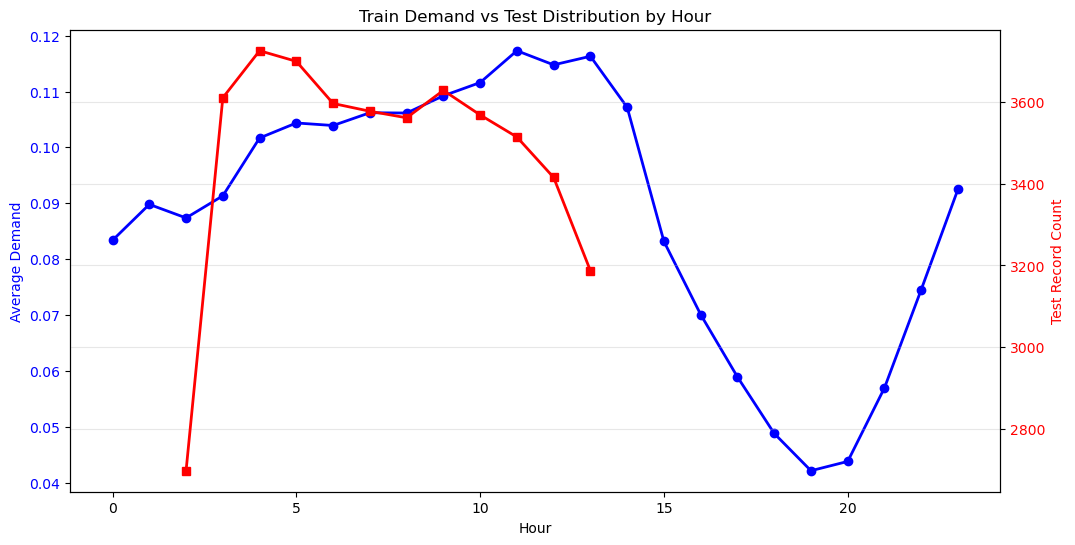

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Extract hour
# -----------------------------

train_plot = train_fe.copy()
test_plot = test_df.copy()

train_plot["hour"] = (
    train_plot["timestamp"]
    .str.split(":")
    .str[0]
    .astype(int)
)

test_plot["hour"] = (
    test_plot["timestamp"]
    .str.split(":")
    .str[0]
    .astype(int)
)

# -----------------------------
# Aggregate
# -----------------------------

train_hourly = (
    train_plot
    .groupby("hour")["demand"]
    .mean()
    .reset_index()
)

test_hourly = (
    test_plot
    .groupby("hour")
    .size()
    .reset_index(name="count")
)

# -----------------------------
# Plot
# -----------------------------

fig, ax1 = plt.subplots(figsize=(12, 6))

# Train Demand Curve (Blue)
ax1.plot(
    train_hourly["hour"],
    train_hourly["demand"],
    marker="o",
    linewidth=2,
    color="blue",
    label="Train Avg Demand"
)

ax1.set_xlabel("Hour")
ax1.set_ylabel(
    "Average Demand",
    color="blue"
)

ax1.tick_params(
    axis="y",
    labelcolor="blue"
)

# Test Distribution Curve (Red)
ax2 = ax1.twinx()

ax2.plot(
    test_hourly["hour"],
    test_hourly["count"],
    marker="s",
    linewidth=2,
    color="red",
    label="Test Record Count"
)

ax2.set_ylabel(
    "Test Record Count",
    color="red"
)

ax2.tick_params(
    axis="y",
    labelcolor="red"
)

plt.title(
    "Train Demand vs Test Distribution by Hour"
)

plt.grid(alpha=0.3)

plt.show()

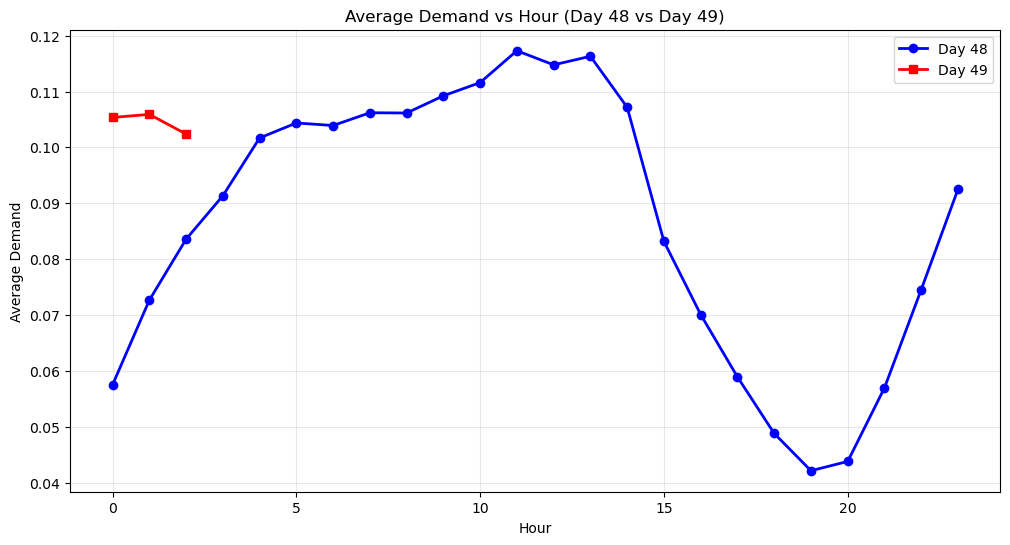

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Day 48
# -----------------------------

day48 = (
    train_fe[
        train_fe["day"] == 48
    ]
    .groupby("hour")["demand"]
    .mean()
    .reset_index()
)

# -----------------------------
# Day 49
# -----------------------------

day49 = (
    train_fe[
        train_fe["day"] == 49
    ]
    .groupby("hour")["demand"]
    .mean()
    .reset_index()
)

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(12,6))

plt.plot(
    day48["hour"],
    day48["demand"],
    marker="o",
    linewidth=2,
    color="blue",
    label="Day 48"
)

plt.plot(
    day49["hour"],
    day49["demand"],
    marker="s",
    linewidth=2,
    color="red",
    label="Day 49"
)

plt.xlabel("Hour")
plt.ylabel("Average Demand")

plt.title(
    "Average Demand vs Hour (Day 48 vs Day 49)"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [94]:
day48_geos = set(
    train_fe.loc[
        train_fe["day"] == 48,
        "geohash"
    ]
)

day49_geos = set(
    train_fe.loc[
        train_fe["day"] == 49,
        "geohash"
    ]
)

common_geos = list(
    day48_geos.intersection(day49_geos)
)

print(f"Common geohashes: {len(common_geos)}")
print(common_geos[:20])

Common geohashes: 1070
['qp0d0m', 'qp09f7', 'qp09bk', 'qp08gm', 'qp02z9', 'qp096r', 'qp03zs', 'qp0992', 'qp03q7', 'qp03tf', 'qp03xn', 'qp09uz', 'qp094d', 'qp09mr', 'qp09qp', 'qp0d4e', 'qp0938', 'qp0d15', 'qp099t', 'qp08gx']


In [98]:
target_geohash = 'qp096r'
print(target_geohash)

qp096r


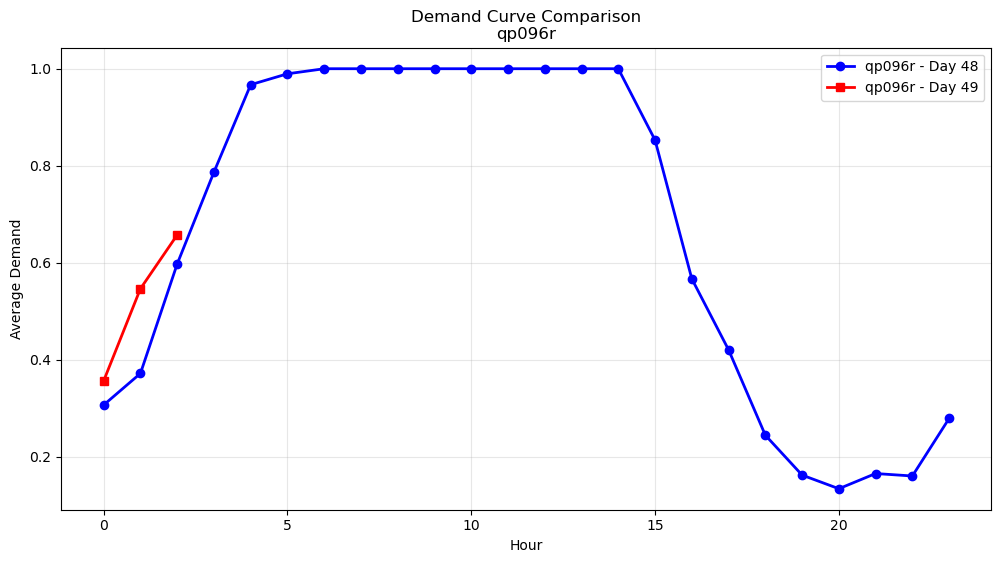

In [99]:
import matplotlib.pyplot as plt

geo_df = train_fe[
    train_fe["geohash"] == target_geohash
].copy()

day48 = (
    geo_df[
        geo_df["day"] == 48
    ]
    .groupby("hour")["demand"]
    .mean()
    .reset_index()
)

day49 = (
    geo_df[
        geo_df["day"] == 49
    ]
    .groupby("hour")["demand"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    day48["hour"],
    day48["demand"],
    marker="o",
    linewidth=2,
    color="blue",
    label=f"{target_geohash} - Day 48"
)

plt.plot(
    day49["hour"],
    day49["demand"],
    marker="s",
    linewidth=2,
    color="red",
    label=f"{target_geohash} - Day 49"
)

plt.xlabel("Hour")
plt.ylabel("Average Demand")

plt.title(
    f"Demand Curve Comparison\n{target_geohash}"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [97]:
counts = (
    train_fe
    .groupby(
        ["geohash", "day"]
    )
    .size()
    .unstack(fill_value=0)
)

counts["total"] = (
    counts[48]
    + counts[49]
)

best_geo = (
    counts
    .sort_values(
        "total",
        ascending=False
    )
    .index[0]
)

print(best_geo)

qp096r
